In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
from datetime import timedelta
import logging
import mysql

In [ ]:
# Prepare the DataFrame for the investment window analysis by ensuring proper data types and sorting.
def prepare_data(df, asset_class=None, start=pd.Timestamp.now(), end=pd.DateOffset(months=3)):
    """
    Prepare and clean the DataFrame for analysis.
    Args:
        df: DataFrame with 'TransactionDate', 'TransactionClass', and 'Available' columns
        asset_class: String to filter TransactionClass column (e.g., 'US Agencies')
        start_date_parameter: Starting date for analysis, defaults to today
        end_date_parameter: Ending date for analysis, defaults to 3 months from today
    Returns:
        DataFrame: Cleaned and sorted DataFrame
    """
    # Define start and end dates
    start_date = pd.Timestamp(start).normalize()
    end_date = pd.Timestamp(end).normalize()
    
    # 1. Filter the data within the date range
    data = df[(df['TransactionDate'] >= start_date) & (df['TransactionDate'] <= end_date)].copy()
    
    # 2. Filter by asset class if specified
    if asset_class is not None:
        # Check if asset_class exists in TransactionClass column
        if asset_class not in df['TransactionClass'].unique():
            raise ValueError(f"Asset class '{asset_class}' not found in data")
        data = data[data['TransactionClass'] == asset_class].copy()
        if data.empty:
            raise ValueError(f"No data found for asset class: {asset_class}")

    # Set the TransactionDate to datetime
    data['TransactionDate'] = pd.to_datetime(data['TransactionDate'])

    # Sort
    data = data.sort_values('TransactionDate').reset_index(drop=True)
    data['TransactionClass'] = asset_class if asset_class else 'Not Specified'
    return data[['TransactionDate', 'Available','TransactionClass']]

In [ ]:
# MAIN (DEBUG)
#     analyze_balance_data() for running the asset class balances processing

# In prod we'll be looping over each asset class and process the investment windows one by one
asset_classes = ['Certificate of Deposit', 'Mutual Fund', 'Commercial Paper', 'Money Market', 'US Treasuries', 'US Agencies']
asset_index = 2
# Load data
running_balances = pd.read_pickle('running_balances.pkl')
data = prepare_data(running_balances, asset_classes[asset_index], '2025-09-04', '2025-10-31')

#Display
# print (asset_classes[asset_index],":\n")
# print(data)
with pd.option_context('display.max_columns', None,
                       'display.max_rows', None,
                       'display.width', None,
                       'display.expand_frame_repr', False):
    pd.options.display.float_format = '${:,.2f}'.format
    display(data.head(10))


,TransactionDate,Available,TransactionClass
0,2025-09-04,"$9,358,278.49",Commercial Paper
1,2025-09-05,"$9,546,428.49",Commercial Paper
2,2025-09-06,"$9,546,428.49",Commercial Paper
3,2025-09-07,"$9,546,428.49",Commercial Paper
4,2025-09-08,"$31,782,170.49",Commercial Paper
5,2025-09-09,"$40,107,170.49",Commercial Paper
6,2025-09-10,"$10,135,354.49",Commercial Paper
7,2025-09-11,"$110,183,544.49",Commercial Paper
8,2025-09-12,"$82,529,226.49",Commercial Paper
9,2025-09-13,"$82,529,226.49",Commercial Paper


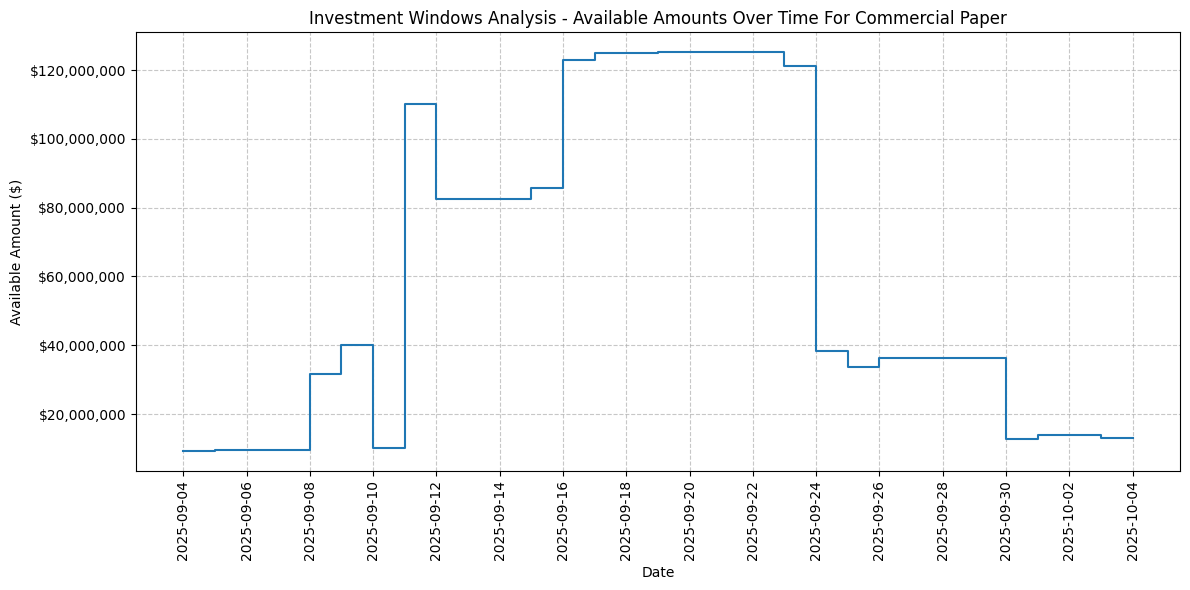

In [58]:
# Create a line plot using matplotlib

results_df = data.copy()

# Filter for first 30 days
first_date = results_df['TransactionDate'].min()
last_date = first_date + pd.Timedelta(days=30)
filtered_df = results_df[results_df['TransactionDate'] <= last_date]

plt.figure(figsize=(12, 6))
plt.step(filtered_df['TransactionDate'], filtered_df['Available'], where='post', label='Available Amount')

# Format y-axis to show dollar amounts
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Format x-axis to show dates with adaptive frequency
date_range = pd.date_range(first_date, last_date)
if len(date_range) > 15:
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
else:
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Available Amount ($)')
plt.title('Investment Windows Analysis - Available Amounts Over Time For ' + asset_classes[asset_index])

# Add grid
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()

In [62]:
"""
df: DataFrame with 'TransactionDate' and 'Available' columns
threshold = 1,000,000 - minimum balance to consider

Returns intervals as follows:
- use the available balance for eachday
- derermine intervals for for how long the balance remains above a certain threshold of $1,000,000.
- So the result: 
- $16,860,124.55 is available from 9/4/2025 until the end
- $83,634,124.55 is available from 9/8/2025 until 9/9/2025
- $41,258,124.55 is available from 9/10/2025 until 9/24/2025
- and so on...
- add a column to the result dataframe with the duration of each interval in days
- add a column with the amount of how much more is available compared to the previous interval
"""

def find_balance_intervals(df, threshold=1_000_000):
    # Initialize lists to store interval data
    start_dates = []
    end_dates = []
    amounts = []
    
    # Initialize variables for tracking intervals
    current_amount = df.iloc[0]['Available']
    current_start = df.iloc[0]['TransactionDate']
    prev_date = df.iloc[0]['TransactionDate']
    
    # Iterate through the dataframe by date (day by day)
    for i in range(1, len(df)):
        current_row = df.iloc[i]
        
        # If amount changes or we reach the end
        if current_row['Available'] != current_amount or i == len(df) - 1:
            # If current amount is above threshold, save the interval
            if current_amount >= threshold:
                start_dates.append(current_start)
                end_dates.append(prev_date)
                amounts.append(current_amount)
            
            # Start new interval
            current_amount = current_row['Available']
            current_start = current_row['TransactionDate']
        
        prev_date = current_row['TransactionDate']
    
    # Create result dataframe
    intervals_df = pd.DataFrame({
        'StartDate': start_dates,
        'EndDate': end_dates,
        'Amount': amounts
    })
    
    # Calculate duration in days
    intervals_df['Duration'] = (intervals_df['EndDate'] - intervals_df['StartDate']).dt.days + 1
    
    # Calculate amount change
    intervals_df['Difference'] = intervals_df['Amount'].diff()
    # Set the first row AmountChange to equal the Amount
    intervals_df.loc[0, 'Difference'] = intervals_df.loc[0, 'Amount']

    # Drop rows where duration <= 1 day
    # intervals_df = intervals_df[intervals_df['Duration'] > 1].reset_index(drop=True)
    
    return intervals_df

# Run the function on the data
intervals = find_balance_intervals(data)
display(intervals)

,StartDate,EndDate,Amount,Duration,Difference
0,2025-09-04,2025-09-04,"$9,358,278.49",1,"$9,358,278.49"
1,2025-09-05,2025-09-07,"$9,546,428.49",3,"$188,150.00"
2,2025-09-08,2025-09-08,"$31,782,170.49",1,"$22,235,742.00"
3,2025-09-09,2025-09-09,"$40,107,170.49",1,"$8,325,000.00"
4,2025-09-10,2025-09-10,"$10,135,354.49",1,"$-29,971,816.00"
5,2025-09-11,2025-09-11,"$110,183,544.49",1,"$100,048,190.00"
6,2025-09-12,2025-09-14,"$82,529,226.49",3,"$-27,654,318.00"
7,2025-09-15,2025-09-15,"$85,864,226.49",1,"$3,335,000.00"
8,2025-09-16,2025-09-16,"$123,010,048.49",1,"$37,145,822.00"
9,2025-09-17,2025-09-18,"$124,923,470.49",2,"$1,913,422.00"
